# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [2]:
import numpy as np
import scipy.linalg as la
import scipy.interpolate as interp
import matplotlib.pyplot as plt
import time
print("=" * 70)
print("ZADANIE 1")
print("=" * 70)
 
# ─── Macierz Hilberta 15×15 ───────────────────────────────────────────────────
print("\n--- Macierz Hilberta 15×15 ---")
A_hilbert = la.hilbert(15)
b_hilbert  = np.random.uniform(0, 100, 15)
 
cond_hilbert = np.linalg.cond(A_hilbert)
print(f"Współczynnik uwarunkowania macierzy Hilberta: {cond_hilbert:.6e}")
 
# Macierze losowe
sizes = [(100, 100), (1000, 1000), (1000000, 1000000)]
# Uwaga: macierz 1 000 000 × 1 000 000 jest zbyt duża dla RAM – pomijamy ją
# i liczymy tylko 100×100 oraz 1000×1000.
for n in [100, 1000]:
    A_rand = np.random.uniform(0, 100, (n, n))
    cond_rand = np.linalg.cond(A_rand)
    print(f"Współczynnik uwarunkowania macierzy losowej {n}×{n}: {cond_rand:.6e}")
 
# ─── Rozwiązania układu (Hilbert 15×15) ──────────────────────────────────────
print("\n--- Rozwiązania układu Ax = b (Hilbert 15×15) ---")
 
# 1) Jawna odwrotność
A_inv = np.linalg.inv(A_hilbert)
x_inv = A_inv @ b_hilbert
res_inv = np.linalg.norm(A_hilbert @ x_inv - b_hilbert)
print(f"[1] Jawna odwrotność         – residuum: {res_inv:.6e}")
 
# 2a) Rozkład LU – odwrotności L i U
P, L, U = la.lu(A_hilbert)
# Px = b  →  LUx = P^T b
Pb    = P.T @ b_hilbert
L_inv = np.linalg.inv(L)
U_inv = np.linalg.inv(U)
x_lu_inv = U_inv @ (L_inv @ Pb)
res_lu_inv = np.linalg.norm(A_hilbert @ x_lu_inv - b_hilbert)
print(f"[2a] LU (odwrotności L, U)   – residuum: {res_lu_inv:.6e}")
 
# 2b) Rozkład LU – podstawianie wsteczne
y_lu  = la.solve_triangular(L, Pb, lower=True)
x_lu  = la.solve_triangular(U, y_lu, lower=False)
res_lu = np.linalg.norm(A_hilbert @ x_lu - b_hilbert)
print(f"[2b] LU (podstawianie)       – residuum: {res_lu:.6e}")
 
# 3a) Rozkład QR – odwrotności Q i R
Q, R = np.linalg.qr(A_hilbert)
Q_inv = np.linalg.inv(Q)
R_inv = np.linalg.inv(R)
x_qr_inv = R_inv @ (Q_inv @ b_hilbert)
res_qr_inv = np.linalg.norm(A_hilbert @ x_qr_inv - b_hilbert)
print(f"[3a] QR (odwrotności Q, R)   – residuum: {res_qr_inv:.6e}")
 
# 3b) Rozkład QR – podstawianie wsteczne
x_qr = la.solve_triangular(R, Q.T @ b_hilbert, lower=False)
res_qr = np.linalg.norm(A_hilbert @ x_qr - b_hilbert)
print(f"[3b] QR (podstawianie)       – residuum: {res_qr:.6e}")
 
# 4) Metoda iteracyjna – Gauss-Seidel
def gauss_seidel(A, b, tol=1e-10, max_iter=10000):
    n = len(b)
    x = np.zeros(n)
    for _ in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            s1 = np.dot(A[i, :i],  x_new[:i])
            s2 = np.dot(A[i, i+1:], x[i+1:])
            x_new[i] = (b[i] - s1 - s2) / A[i, i]
        if np.linalg.norm(x_new - x) < tol:
            return x_new
        x = x_new
    return x
 
x_gs  = gauss_seidel(A_hilbert, b_hilbert)
res_gs = np.linalg.norm(A_hilbert @ x_gs - b_hilbert)
print(f"[4]  Gauss-Seidel            – residuum: {res_gs:.6e}")
 
# 5) numpy.linalg.solve
x_np  = np.linalg.solve(A_hilbert, b_hilbert)
res_np = np.linalg.norm(A_hilbert @ x_np - b_hilbert)
print(f"[5]  numpy.linalg.solve      – residuum: {res_np:.6e}")
 
# ─── Porównanie wydajności (100 powtórzeń) ────────────────────────────────────
print("\n--- Porównanie czasu wykonania (100 powtórzeń) ---")
REPS = 100
 
t0 = time.perf_counter()
for _ in range(REPS):
    np.linalg.inv(A_hilbert) @ b_hilbert
print(f"[1] Jawna odwrotność:        {(time.perf_counter()-t0)/REPS*1000:.4f} ms")
 
t0 = time.perf_counter()
for _ in range(REPS):
    P2, L2, U2 = la.lu(A_hilbert)
    Pb2 = P2.T @ b_hilbert
    la.solve_triangular(U2, la.solve_triangular(L2, Pb2, lower=True))
print(f"[2b] LU (podstawianie):     {(time.perf_counter()-t0)/REPS*1000:.4f} ms")
 
t0 = time.perf_counter()
for _ in range(REPS):
    Q2, R2 = np.linalg.qr(A_hilbert)
    la.solve_triangular(R2, Q2.T @ b_hilbert)
print(f"[3b] QR (podstawianie):     {(time.perf_counter()-t0)/REPS*1000:.4f} ms")
 
t0 = time.perf_counter()
for _ in range(REPS):
    np.linalg.solve(A_hilbert, b_hilbert)
print(f"[5]  numpy.linalg.solve:    {(time.perf_counter()-t0)/REPS*1000:.4f} ms")

ZADANIE 1

--- Macierz Hilberta 15×15 ---
Współczynnik uwarunkowania macierzy Hilberta: 3.675683e+17
Współczynnik uwarunkowania macierzy losowej 100×100: 1.085733e+03
Współczynnik uwarunkowania macierzy losowej 1000×1000: 4.082663e+04

--- Rozwiązania układu Ax = b (Hilbert 15×15) ---
[1] Jawna odwrotność         – residuum: 2.337944e+02
[2a] LU (odwrotności L, U)   – residuum: 1.822131e+02
[2b] LU (podstawianie)       – residuum: 1.402375e+02
[3a] QR (odwrotności Q, R)   – residuum: 7.217216e+01
[3b] QR (podstawianie)       – residuum: 8.975793e+01
[4]  Gauss-Seidel            – residuum: 7.036971e+01
[5]  numpy.linalg.solve      – residuum: 1.024352e+02

--- Porównanie czasu wykonania (100 powtórzeń) ---
[1] Jawna odwrotność:        0.0129 ms
[2b] LU (podstawianie):     0.0827 ms
[3b] QR (podstawianie):     0.0681 ms
[5]  numpy.linalg.solve:    0.0089 ms


# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.


ZADANIE 2

Pierwsza funkcja – f(0.43) ≈ 2.360605
(Wartość referencyjna e^0.43 ≈ 1.537258)


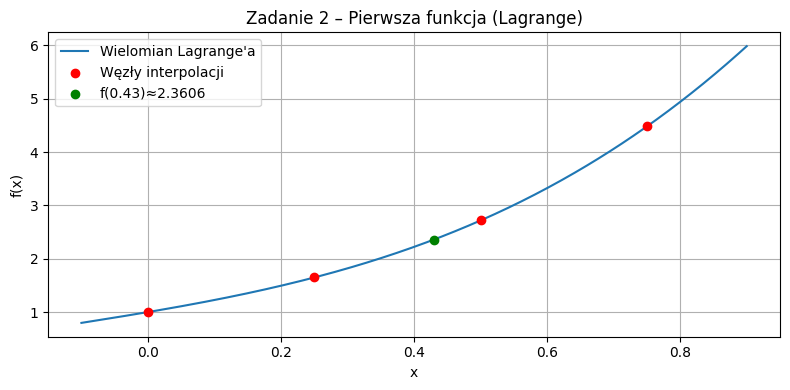


Druga funkcja  – f2(0.25) ≈ -0.210337


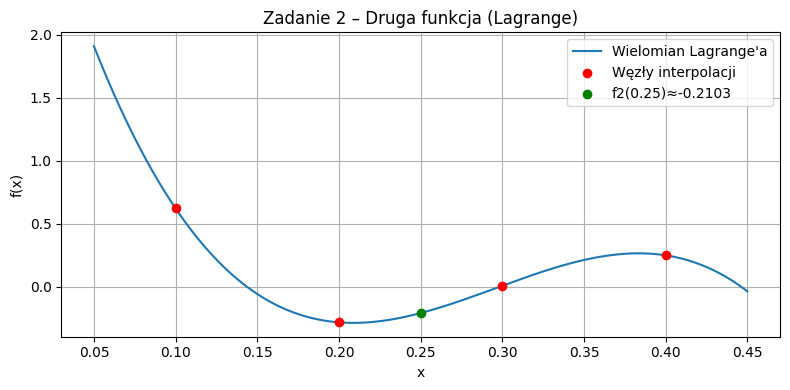

In [3]:
import numpy as np
import scipy.linalg as la
import scipy.interpolate as interp
import matplotlib.pyplot as plt
import time
print("\n" + "=" * 70)
print("ZADANIE 2")
print("=" * 70)
 
# ─── Pierwsza funkcja ─────────────────────────────────────────────────────────
x1 = np.array([0.0, 0.25, 0.5, 0.75])
y1 = np.array([1.0, 1.64872, 2.71828, 4.48169])
 
poly1 = interp.lagrange(x1, y1)
val1  = poly1(0.43)
print(f"\nPierwsza funkcja – f(0.43) ≈ {val1:.6f}")
print(f"(Wartość referencyjna e^0.43 ≈ {np.exp(0.43):.6f})")
 
x1_plot = np.linspace(-0.1, 0.9, 400)
plt.figure(figsize=(8, 4))
plt.plot(x1_plot, poly1(x1_plot), label="Wielomian Lagrange'a")
plt.scatter(x1, y1, color="red", zorder=5, label="Węzły interpolacji")
plt.scatter([0.43], [val1], color="green", zorder=6, label=f"f(0.43)≈{val1:.4f}")
plt.title("Zadanie 2 – Pierwsza funkcja (Lagrange)")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("zadanie2_funkcja1.png", dpi=150)
plt.show()
 
# ─── Druga funkcja ────────────────────────────────────────────────────────────
x2 = np.array([0.1, 0.2, 0.3, 0.4])
y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])
 
poly2 = interp.lagrange(x2, y2)
val2  = poly2(0.25)
print(f"\nDruga funkcja  – f2(0.25) ≈ {val2:.6f}")
 
x2_plot = np.linspace(0.05, 0.45, 400)
plt.figure(figsize=(8, 4))
plt.plot(x2_plot, poly2(x2_plot), label="Wielomian Lagrange'a")
plt.scatter(x2, y2, color="red", zorder=5, label="Węzły interpolacji")
plt.scatter([0.25], [val2], color="green", zorder=6, label=f"f2(0.25)≈{val2:.4f}")
plt.title("Zadanie 2 – Druga funkcja (Lagrange)")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("zadanie2_funkcja2.png", dpi=150)
plt.show()

***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?


ZADANIE 3


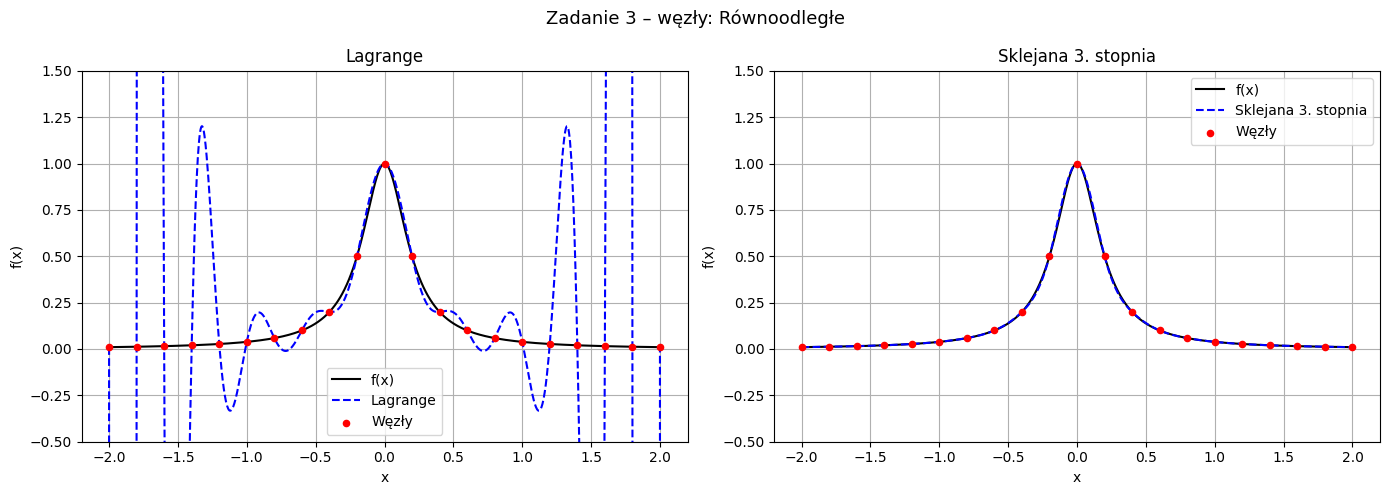

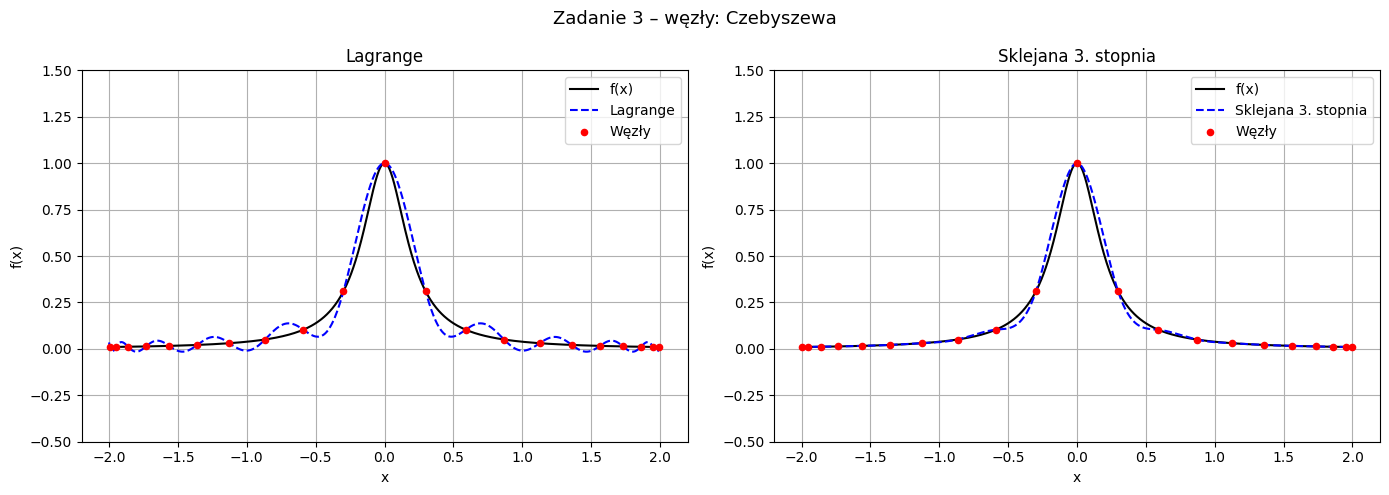

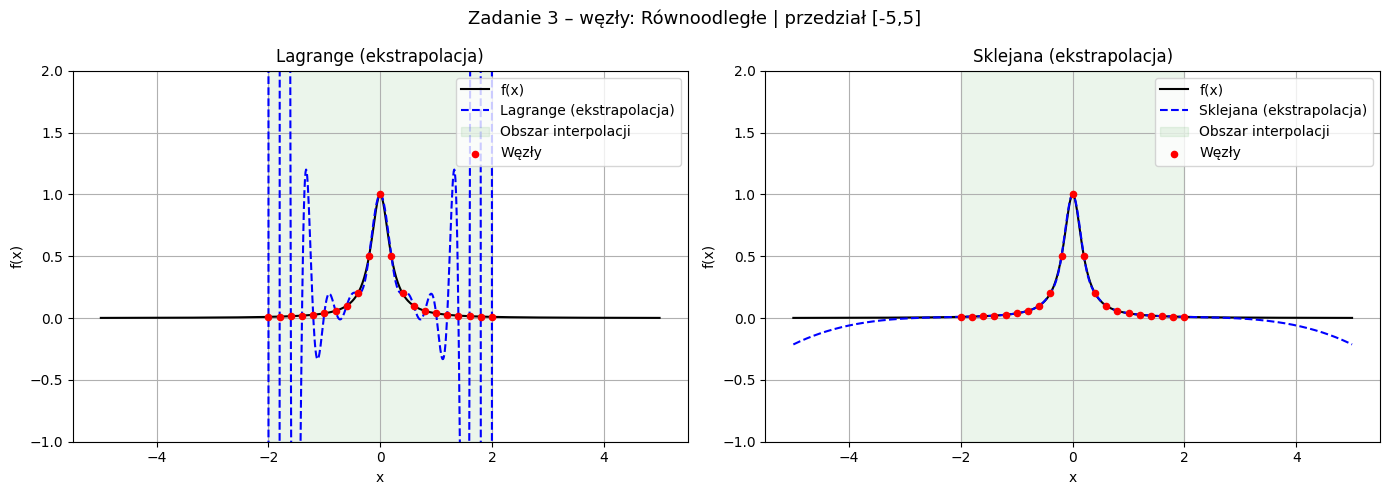

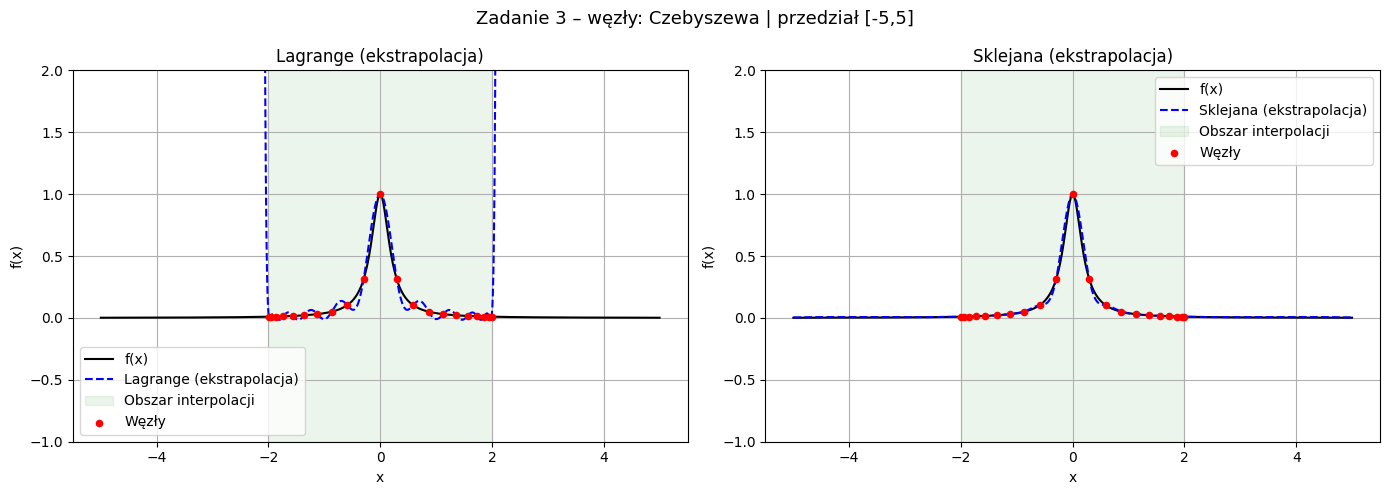


Wszystkie obliczenia zakończone. Wykresy zapisane jako pliki PNG.


In [4]:
import numpy as np
import scipy.linalg as la
import scipy.interpolate as interp
import matplotlib.pyplot as plt
import time
print("\n" + "=" * 70)
print("ZADANIE 3")
print("=" * 70)
 
def runge(x):
    return 1.0 / (25 * x**2 + 1)
 
N = 21  # liczba węzłów
 
# ─── Węzły równoodległe i Czebyszewa ─────────────────────────────────────────
nodes_equal = np.linspace(-2, 2, N)
k = np.arange(N)
nodes_cheby = np.cos((2*k + 1) * np.pi / (2*N))  # na [-1,1]
nodes_cheby = 2 * nodes_cheby                      # skalowanie do [-2,2]
 
# ─── Wykres na [-2, 2] ───────────────────────────────────────────────────────
x_dense = np.linspace(-2, 2, 1000)
 
for label, nodes in [("Równoodległe", nodes_equal), ("Czebyszewa", nodes_cheby)]:
    # Lagrange
    poly_lag = interp.lagrange(nodes, runge(nodes))
    # Sklejana 3. stopnia
    cs = interp.CubicSpline(np.sort(nodes), runge(np.sort(nodes)))
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Zadanie 3 – węzły: {label}", fontsize=13)
 
    for ax, name, approx in zip(
        axes,
        ["Lagrange", "Sklejana 3. stopnia"],
        [poly_lag,   cs]
    ):
        ax.plot(x_dense, runge(x_dense),  "k-",  lw=1.5, label="f(x)")
        ax.plot(x_dense, approx(x_dense), "b--", lw=1.5, label=name)
        ax.scatter(nodes, runge(nodes), color="red", zorder=5, s=20,
                   label="Węzły")
        ax.set_ylim(-0.5, 1.5)
        ax.set_title(name); ax.legend(); ax.grid(True)
        ax.set_xlabel("x"); ax.set_ylabel("f(x)")
 
    plt.tight_layout()
    plt.savefig(f"zadanie3_{label.lower().replace(' ','_')}_2.png", dpi=150)
    plt.show()
 
# ─── Wykres na [-5, 5] ───────────────────────────────────────────────────────
x_wide = np.linspace(-5, 5, 1000)
 
for label, nodes in [("Równoodległe", nodes_equal), ("Czebyszewa", nodes_cheby)]:
    poly_lag = interp.lagrange(nodes, runge(nodes))
    cs = interp.CubicSpline(np.sort(nodes), runge(np.sort(nodes)))
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Zadanie 3 – węzły: {label} | przedział [-5,5]", fontsize=13)
 
    for ax, name, approx in zip(
        axes,
        ["Lagrange (ekstrapolacja)", "Sklejana (ekstrapolacja)"],
        [poly_lag, cs]
    ):
        ax.plot(x_wide, runge(x_wide),   "k-",  lw=1.5, label="f(x)")
        ax.plot(x_wide, approx(x_wide),  "b--", lw=1.5, label=name)
        ax.axvspan(-2, 2, alpha=0.08, color="green", label="Obszar interpolacji")
        ax.scatter(nodes, runge(nodes), color="red", zorder=5, s=20,
                   label="Węzły")
        ax.set_ylim(-1, 2)
        ax.set_title(name); ax.legend(); ax.grid(True)
        ax.set_xlabel("x"); ax.set_ylabel("f(x)")
 
    plt.tight_layout()
    plt.savefig(f"zadanie3_{label.lower().replace(' ','_')}_5.png", dpi=150)
    plt.show()
 
print("\nWszystkie obliczenia zakończone. Wykresy zapisane jako pliki PNG.")
 

***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.
